In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path
from collections import Counter

In [2]:
# Настройка стиля графиков
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# Загрузка конфигурации
with open("../config.json", "r", encoding="utf-8") as f:
    config = json.load(f)

# Загрузка обработанных данных из 01_EDA.ipynb
train_df = pd.read_json(config["paths"]["processed_train"])
test_df = pd.read_json(config["paths"]["processed_test"])

print(f"Train: {train_df.shape}")
print(f"Test: {test_df.shape}")
print(f"\nКолонки: {list(train_df.columns)}")

Train: (16102, 15)
Test: (32277, 15)

Колонки: ['bathrooms', 'bedrooms', 'building_id', 'created', 'description', 'display_address', 'features', 'latitude', 'listing_id', 'longitude', 'manager_id', 'photos', 'price', 'street_address', 'interest_level']


## Анализ features до обработки


Всего уникальных удобств (до очистки): 821

Примеры потенциальных дубликатов:
  Варианты 'laundry': ['**Laundry room code is 3401', 'Elevator & Laundry', 'LAUNDRY', 'Laundry', 'Laundry In Building', 'Laundry In Unit', 'Laundry On Floor', 'Laundry Room', 'Laundry facility on every floor', 'Laundry in Building', 'Laundry in Some Units', 'Laundry in Unit', 'Laundry on every floor', 'Laundry room', 'On-site Laundry', 'On-site laundry', 'Valet Laundry', 'air conditioned laundry facility', 'elevator & Laundry', 'laundry hookup', 'laundry in bldg', 'laundry in building', 'laundry room', 'laundry room as well as housekeeping & dry-cleaning services']
  Варианты 'hardwood': ['HARDWOOD', 'Hardwood', 'Hardwood Flooring', 'Hardwood Flooring Throughout', 'Hardwood Floors', 'Hardwood floors', 'NO FEE HARDWOOD FLOORS', 'boating hardwood floors', 'hardwood floors']

Статистика количества удобств:
  Среднее: 5.44
  Медиана: 5.00
  Минимум: 0
  Максимум: 31


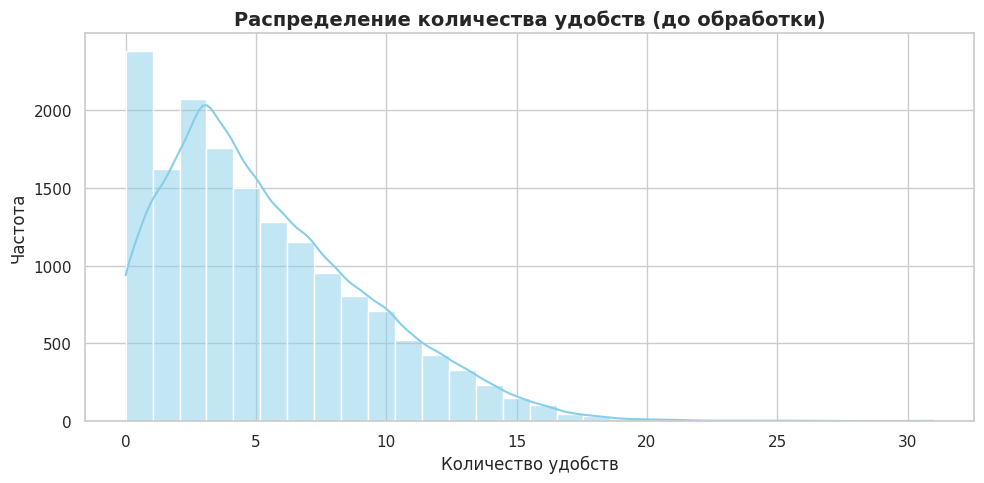


Вывод: Присутствуют дубликаты из-за разного регистра и пробелов.
Необходимо нормализовать названия перед созданием бинарных признаков.


In [3]:
# Подсчет всех уникальных удобств
all_features_raw = []
for features_list in train_df["features"]:
    if isinstance(features_list, list):
        all_features_raw.extend(features_list)

unique_features_raw = set(all_features_raw)
print(f"\nВсего уникальных удобств (до очистки): {len(unique_features_raw)}")

# Примеры дубликатов (разный регистр, пробелы)
print("\nПримеры потенциальных дубликатов:")
sample_features = sorted([f for f in unique_features_raw if 'laundry' in f.lower()])
print(f"  Варианты 'laundry': {sample_features}")

sample_features = sorted([f for f in unique_features_raw if 'hardwood' in f.lower()])
print(f"  Варианты 'hardwood': {sample_features}")

# Распределение количества удобств
train_df["num_features_raw"] = train_df["features"].apply(
    lambda x: len(x) if isinstance(x, list) else 0
)

print(f"\nСтатистика количества удобств:")
print(f"  Среднее: {train_df['num_features_raw'].mean():.2f}")
print(f"  Медиана: {train_df['num_features_raw'].median():.2f}")
print(f"  Минимум: {train_df['num_features_raw'].min()}")
print(f"  Максимум: {train_df['num_features_raw'].max()}")

# Визуализация
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(train_df["num_features_raw"], bins=30, kde=True, ax=ax, color="skyblue")
ax.set_title("Распределение количества удобств (до обработки)", fontsize=14, fontweight="bold")
ax.set_xlabel("Количество удобств")
ax.set_ylabel("Частота")
plt.tight_layout()
plt.show()

print("\nВывод: Присутствуют дубликаты из-за разного регистра и пробелов.")
print("Необходимо нормализовать названия перед созданием бинарных признаков.")

## Очистка features (lowercase + remove spaces)

In [4]:
def clean_features(features_list):
    if not isinstance(features_list, list):
        return []
    
    cleaned = []
    for item in features_list:
        # Приводим к строке, нижнему регистру, удаляем пробелы
        cleaned_item = str(item).lower().replace(" ", "")
        cleaned.append(cleaned_item)
    
    return cleaned

# Применяем очистку
train_df["features_cleaned"] = train_df["features"].apply(clean_features)
test_df["features_cleaned"] = test_df["features"].apply(clean_features)

# Проверка результата
print("\nПримеры до и после очистки:")
for idx in range(3):
    print(f"\nЗапись {idx}:")
    print(f"  До: {train_df['features'].iloc[idx]}")
    print(f"  После: {train_df['features_cleaned'].iloc[idx]}")

# Подсчет уникальных после очистки
all_features_cleaned = []
for features_list in train_df["features_cleaned"]:
    all_features_cleaned.extend(features_list)

unique_features_cleaned = set(all_features_cleaned)
print(f"\nВсего уникальных удобств (после очистки): {len(unique_features_cleaned)}")
print(f"Сокращение: {len(unique_features_raw)} -> {len(unique_features_cleaned)} ({len(unique_features_raw) - len(unique_features_cleaned)} удалено)")


Примеры до и после очистки:

Запись 0:
  До: ['Doorman', 'Prewar', 'Elevator', 'Dishwasher', 'Laundry in Unit', 'Roof-deck', 'Hardwood Floors', 'High Ceiling', 'Laundry Room']
  После: ['doorman', 'prewar', 'elevator', 'dishwasher', 'laundryinunit', 'roof-deck', 'hardwoodfloors', 'highceiling', 'laundryroom']

Запись 1:
  До: ['Doorman', 'Elevator', 'No Fee', 'Cats Allowed']
  После: ['doorman', 'elevator', 'nofee', 'catsallowed']

Запись 2:
  До: ['Swimming Pool', 'Doorman', 'Elevator', 'Fitness Center', 'Laundry in Building', 'Dishwasher', 'Hardwood Floors', 'No Fee', 'Dogs Allowed', 'Cats Allowed']
  После: ['swimmingpool', 'doorman', 'elevator', 'fitnesscenter', 'laundryinbuilding', 'dishwasher', 'hardwoodfloors', 'nofee', 'dogsallowed', 'catsallowed']

Всего уникальных удобств (после очистки): 686
Сокращение: 821 -> 686 (135 удалено)


In [5]:
print("Подсчет топ 20 после отчистки")
# Подсчет частоты
feature_counter = Counter(all_features_cleaned)
top_20_features = feature_counter.most_common(20)

print("\nТоп-20 наиболее частых удобств:")
for i, (feature, count) in enumerate(top_20_features, 1):
    percentage = count / len(train_df) * 100
    print(f"{i:2d}. {feature}: {count} ({percentage:.1f}%)")

print(f"\nРешение: Создаем бинарные признаки для этих {len(top_20_features)} удобств.")
print("Остальные редкие удобства агрегируем в признак 'num_other_amenities'.")

Подсчет топ 20 после отчистки

Топ-20 наиболее частых удобств:
 1. elevator: 8570 (53.2%)
 2. hardwoodfloors: 7845 (48.7%)
 3. catsallowed: 7612 (47.3%)
 4. dogsallowed: 7126 (44.3%)
 5. doorman: 6875 (42.7%)
 6. dishwasher: 6861 (42.6%)
 7. laundryinbuilding: 6351 (39.4%)
 8. nofee: 6027 (37.4%)
 9. fitnesscenter: 4272 (26.5%)
10. laundryinunit: 3094 (19.2%)
11. pre-war: 2920 (18.1%)
12. roofdeck: 2129 (13.2%)
13. outdoorspace: 1765 (11.0%)
14. diningroom: 1603 (10.0%)
15. highspeedinternet: 1411 (8.8%)
16. balcony: 940 (5.8%)
17. swimmingpool: 894 (5.6%)
18. newconstruction: 854 (5.3%)
19. loft: 766 (4.8%)
20. terrace: 740 (4.6%)

Решение: Создаем бинарные признаки для этих 20 удобств.
Остальные редкие удобства агрегируем в признак 'num_other_amenities'.


## Создание бинарных признаков для топ-20/Создание признака num_other_amenities

In [6]:
# Список топ-20 удобств
top_20_names = [feature for feature, _ in top_20_features]

def create_binary_features(df, feature_names, source_col="features_cleaned"):
    """
    Создает бинарные признаки (0/1) для каждого удобства из списка.
    """
    for feature in feature_names:
        df[feature] = df[source_col].apply(
            lambda x: 1 if feature in x else 0
        )
    return df

# Применяем к train и test
train_df = create_binary_features(train_df, top_20_names)
test_df = create_binary_features(test_df, top_20_names)

print(f"\nСоздано {len(top_20_names)} бинарных признаков:")
print(top_20_names)

# Проверка
print(f"\nПример бинарных признаков (первые 5 записей):")
display(train_df[top_20_names[:5]].head())


Создано 20 бинарных признаков:
['elevator', 'hardwoodfloors', 'catsallowed', 'dogsallowed', 'doorman', 'dishwasher', 'laundryinbuilding', 'nofee', 'fitnesscenter', 'laundryinunit', 'pre-war', 'roofdeck', 'outdoorspace', 'diningroom', 'highspeedinternet', 'balcony', 'swimmingpool', 'newconstruction', 'loft', 'terrace']

Пример бинарных признаков (первые 5 записей):


,elevator,hardwoodfloors,catsallowed,dogsallowed,doorman
0,1,1,0,0,1
1,1,0,1,0,1
2,1,1,1,1,1
3,0,0,1,0,0
4,1,1,0,0,0



Статистика 'num_other_amenities' (train):
  Среднее: 0.55
  Медиана: 0.00
  Минимум: 0
  Максимум: 24


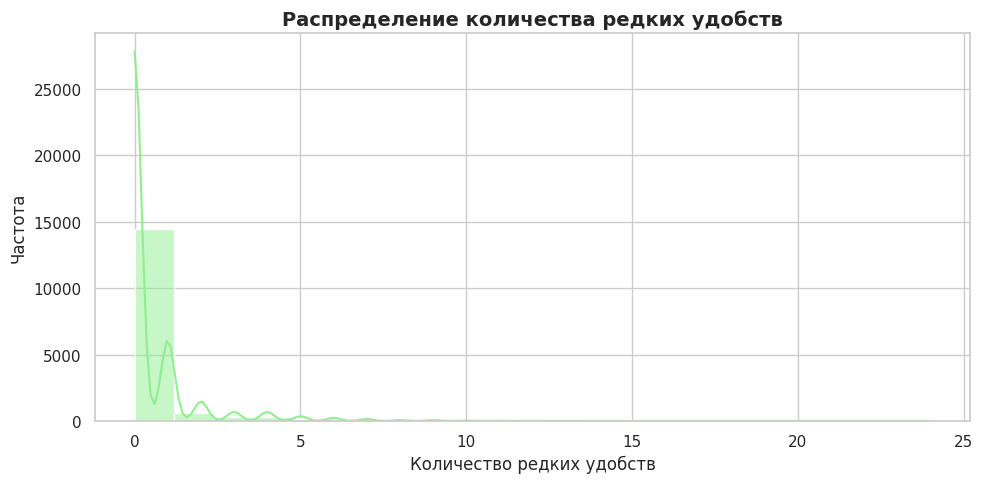


Вывод: В среднем 0.6 редких удобств на квартиру.


In [7]:
def count_other_amenities(features_list, top_features):
    """
    Подсчитывает количество удобств, не входящих в топ-N.
    """
    if not isinstance(features_list, list):
        return 0
    
    other_count = 0
    for item in features_list:
        if item not in top_features:
            other_count += 1
    
    return other_count

# Применяем
train_df["num_other_amenities"] = train_df["features_cleaned"].apply(
    lambda x: count_other_amenities(x, top_20_names)
)
test_df["num_other_amenities"] = test_df["features_cleaned"].apply(
    lambda x: count_other_amenities(x, top_20_names)
)

# Статистика
print(f"\nСтатистика 'num_other_amenities' (train):")
print(f"  Среднее: {train_df['num_other_amenities'].mean():.2f}")
print(f"  Медиана: {train_df['num_other_amenities'].median():.2f}")
print(f"  Минимум: {train_df['num_other_amenities'].min()}")
print(f"  Максимум: {train_df['num_other_amenities'].max()}")

# Визуализация
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(train_df["num_other_amenities"], bins=20, kde=True, ax=ax, color="lightgreen")
ax.set_title("Распределение количества редких удобств", fontsize=14, fontweight="bold")
ax.set_xlabel("Количество редких удобств")
ax.set_ylabel("Частота")
plt.tight_layout()
plt.show()

print(f"\nВывод: В среднем {train_df['num_other_amenities'].mean():.1f} редких удобств на квартиру.")

СОЗДАНИЕ ПРИЗНАКА 'NUM_AMENITIES'

Статистика 'num_amenities' (train):
  Среднее: 5.44
  Медиана: 5.00


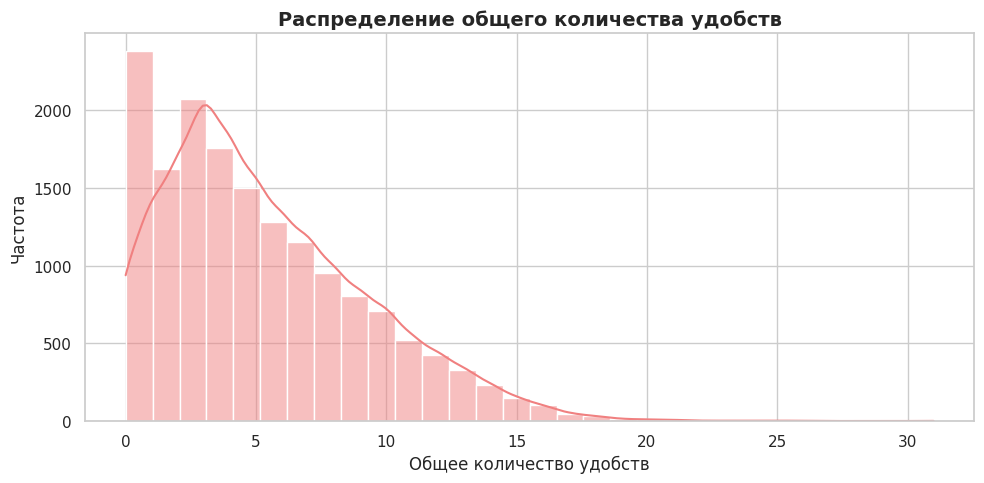

In [8]:
print("СОЗДАНИЕ ПРИЗНАКА 'NUM_AMENITIES'")

# Общее количество удобств (уже было посчитано, но переименуем)
train_df["num_amenities"] = train_df["num_features_raw"]
test_df["num_amenities"] = test_df["features"].apply(
    lambda x: len(x) if isinstance(x, list) else 0
)

print(f"\nСтатистика 'num_amenities' (train):")
print(f"  Среднее: {train_df['num_amenities'].mean():.2f}")
print(f"  Медиана: {train_df['num_amenities'].median():.2f}")

# Визуализация
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(train_df["num_amenities"], bins=30, kde=True, ax=ax, color="lightcoral")
ax.set_title("Распределение общего количества удобств", fontsize=14, fontweight="bold")
ax.set_xlabel("Общее количество удобств")
ax.set_ylabel("Частота")
plt.tight_layout()
plt.show()

## Ordinal encoding для interest_level

In [9]:
# Маппинг
encoding_map = {"low": 0, "medium": 1, "high": 2}

train_df["interest_level_encoded"] = train_df["interest_level"].map(encoding_map)
test_df["interest_level_encoded"] = test_df["interest_level"].map(encoding_map)

print(f"\nМаппинг: {encoding_map}")
print(f"\nПример кодирования:")
display(train_df[["interest_level", "interest_level_encoded"]].head(10))

# Проверка на пропуски
nulls_train = train_df["interest_level_encoded"].isnull().sum()
nulls_test = test_df["interest_level_encoded"].isnull().sum()
print(f"\nПропуски после кодирования:")
print(f"  Train: {nulls_train}")
print(f"  Test: {nulls_test}")

if nulls_train > 0 or nulls_test > 0:
    print("\nВнимание: Обнаружены неизвестные категории!")
    print("Необходимо обработать пропуски.")


Маппинг: {'low': 0, 'medium': 1, 'high': 2}

Пример кодирования:


,interest_level,interest_level_encoded
0,low,0
1,low,0
2,medium,1
3,medium,1
4,low,0
5,medium,1
6,low,0
7,medium,1
8,medium,1
9,low,0



Пропуски после кодирования:
  Train: 0
  Test: 0


In [10]:
print(train_df['created'].dtype)
print(train_df['created'])

object
0        2016-04-23 01:41:45
1        2016-04-12 04:25:33
2        2016-04-02 05:46:07
3        2016-04-06 08:10:34
4        2016-04-23 02:53:54
                ...         
16097    2016-04-05 03:58:33
16098    2016-04-02 02:25:31
16099    2016-04-26 05:42:03
16100    2016-04-19 02:47:33
16101    2016-04-20 05:34:00
Name: created, Length: 16102, dtype: object


## Временные признаки из created

datetime64[ns]
0   2016-04-23 01:41:45
1   2016-04-12 04:25:33
2   2016-04-02 05:46:07
3   2016-04-06 08:10:34
4   2016-04-23 02:53:54
Name: created, dtype: datetime64[ns]

Созданные временные признаки:
  - day_of_week (0=Monday, 6=Sunday)
  - month
  - day
  - is_weekend (1=Weekend, 0=Weekday)

Пример временных признаков:


,created,day_of_week,month,day,is_weekend
0,2016-04-23 01:41:45,5,4,23,1
1,2016-04-12 04:25:33,1,4,12,0
2,2016-04-02 05:46:07,5,4,2,1
3,2016-04-06 08:10:34,2,4,6,0
4,2016-04-23 02:53:54,5,4,23,1
5,2016-04-20 05:02:17,2,4,20,0
6,2016-04-12 02:27:38,1,4,12,0
7,2016-04-13 02:17:36,2,4,13,0
8,2016-04-26 05:39:39,1,4,26,0
9,2016-04-21 05:31:06,3,4,21,0


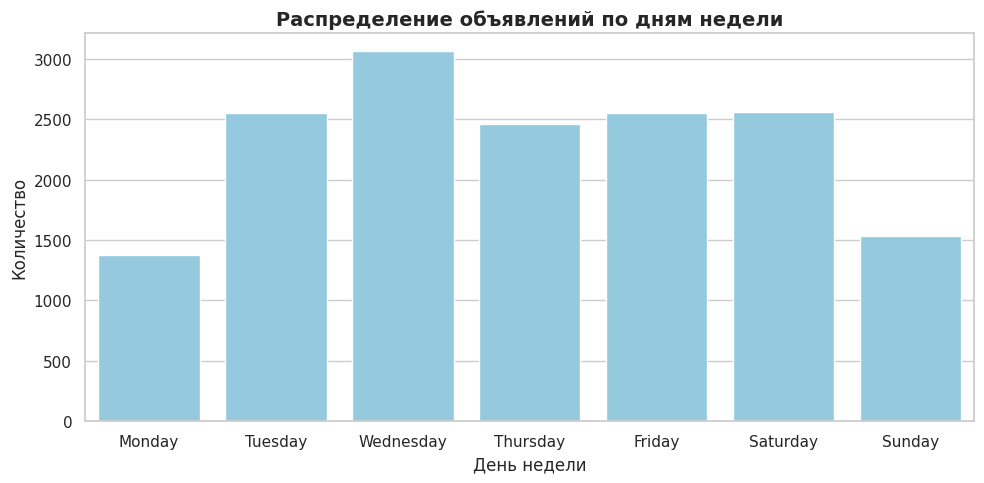

In [11]:
# Конвертация даты
train_df["created"] = pd.to_datetime(train_df["created"])
test_df["created"] = pd.to_datetime(test_df["created"])
print(train_df['created'].dtype)
print(train_df['created'].head())

# Извлечение признаков
def extract_time_features(df, date_col="created"):
    """Извлекает временные признаки из даты."""
    df["day_of_week"] = df[date_col].dt.dayofweek  # 0=Monday, 6=Sunday
    df["month"] = df[date_col].dt.month
    df["day"] = df[date_col].dt.day
    df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)  # 1=Weekend, 0=Weekday
    return df

train_df = extract_time_features(train_df)
test_df = extract_time_features(test_df)

print(f"\nСозданные временные признаки:")
print(f"  - day_of_week (0=Monday, 6=Sunday)")
print(f"  - month")
print(f"  - day")
print(f"  - is_weekend (1=Weekend, 0=Weekday)")

# Пример
print(f"\nПример временных признаков:")
display(train_df[["created", "day_of_week", "month", "day", "is_weekend"]].head(10))

# Визуализация распределения по дням недели
fig, ax = plt.subplots(figsize=(10, 5))
day_names = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
day_counts = train_df["day_of_week"].value_counts().sort_index()
day_counts = day_counts.reindex(range(7), fill_value=0)
sns.barplot(x=day_names, y=day_counts.values, ax=ax, color="skyblue")
ax.set_title("Распределение объявлений по дням недели", fontsize=14, fontweight="bold")
ax.set_xlabel("День недели")
ax.set_ylabel("Количество")
plt.tight_layout()
plt.show()

## ПРОВЕРКА РЕЗУЛЬТАТА

In [12]:
# Список финальных признаков
final_features = [
    "bathrooms", "bedrooms",
    "interest_level_encoded",
    "num_amenities", "num_other_amenities",
    "day_of_week", "month", "day", "is_weekend"
] + top_20_names

print(f"\nФинальный список признаков ({len(final_features)}):")
for i, feature in enumerate(final_features, 1):
    print(f"{i:2d}. {feature}")

# Проверка размерности
print(f"\nРазмерность train: {train_df.shape}")
print(f"Размерность test: {test_df.shape}")

# Проверка пропусков
print(f"\nПропуски в финальных признаках (train):")
nulls = train_df[final_features + ["price"]].isnull().sum()
print(nulls[nulls > 0] if nulls.sum() > 0 else "  Пропуски отсутствуют")

# Пример финального датасета
print(f"\nПример финального датасета (первые 3 записи):")
display(train_df[final_features + ["price"]].head(3))


Финальный список признаков (29):
 1. bathrooms
 2. bedrooms
 3. interest_level_encoded
 4. num_amenities
 5. num_other_amenities
 6. day_of_week
 7. month
 8. day
 9. is_weekend
10. elevator
11. hardwoodfloors
12. catsallowed
13. dogsallowed
14. doorman
15. dishwasher
16. laundryinbuilding
17. nofee
18. fitnesscenter
19. laundryinunit
20. pre-war
21. roofdeck
22. outdoorspace
23. diningroom
24. highspeedinternet
25. balcony
26. swimmingpool
27. newconstruction
28. loft
29. terrace

Размерность train: (16102, 44)
Размерность test: (32277, 43)

Пропуски в финальных признаках (train):
  Пропуски отсутствуют

Пример финального датасета (первые 3 записи):


,bathrooms,bedrooms,interest_level_encoded,num_amenities,num_other_amenities,day_of_week,month,day,is_weekend,elevator,...,roofdeck,outdoorspace,diningroom,highspeedinternet,balcony,swimmingpool,newconstruction,loft,terrace,price
0,1.0,1,0,9,4,5,4,23,1,1,...,0,0,0,0,0,0,0,0,0,5595
1,1.0,1,0,4,0,1,4,12,0,1,...,0,0,0,0,0,0,0,0,0,3095
2,1.0,1,1,10,0,5,4,2,1,1,...,0,0,0,0,0,1,0,0,0,3200


## Сохранение данных

In [13]:
print("СОХРАНЕНИЕ ОБРАБОТАННЫХ ДАННЫХ")

# Создание директории
Path("../dataset/processed").mkdir(parents=True, exist_ok=True)

# Сохранение
train_df.to_json(config["paths"]["processed_train"], orient="records", lines=False)
test_df.to_json(config["paths"]["processed_test"], orient="records", lines=False)

print(f"\nTrain сохранен: {config['paths']['processed_train']}")
print(f"Test сохранен: {config['paths']['processed_test']}")

print(f"\nFeature engineering завершен.")
print(f"Данные готовы для моделирования (03_modeling.ipynb).")

СОХРАНЕНИЕ ОБРАБОТАННЫХ ДАННЫХ

Train сохранен: ../dataset/processed/processed_train.json
Test сохранен: ../dataset/processed/processed_test.json

Feature engineering завершен.
Данные готовы для моделирования (03_modeling.ipynb).
